# ARTI308 - Machine Learning Lab 3

### 1. Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
df = pd.read_csv("coffee_sales.csv")

### 3. Preprocessing

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

### 4. Data Overview

In [8]:
print(df.head())

        date            datetime cash_type  money            coffee_name  \
0 2025-02-08 2025-02-08 14:26:04      cash   15.0                    Tea   
1 2025-02-08 2025-02-08 14:28:26      cash   15.0                    Tea   
2 2025-02-08 2025-02-08 14:33:04      card   20.0               Espresso   
3 2025-02-08 2025-02-08 15:51:04      card   30.0  Chocolate with coffee   
4 2025-02-08 2025-02-08 16:35:01      cash   27.0    Chocolate with milk   

   hour day_of_week  
0    14    Saturday  
1    14    Saturday  
2    14    Saturday  
3    15    Saturday  
4    16    Saturday  


In [9]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 date           0
datetime       0
cash_type      0
money          0
coffee_name    0
hour           0
day_of_week    0
dtype: int64


In [10]:
print("\nShape:", df.shape)


Shape: (262, 7)


In [11]:
print("\nData types:\n", df.dtypes)


Data types:
 date           datetime64[us]
datetime       datetime64[us]
cash_type                 str
money                 float64
coffee_name               str
hour                    int32
day_of_week               str
dtype: object


In [12]:
print("\nDescriptive Statistics:\n", df.describe(include='all'))


Descriptive Statistics:
                               date                    datetime cash_type  \
count                          262                         262       262   
unique                         NaN                         NaN         2   
top                            NaN                         NaN      card   
freq                           NaN                         NaN       182   
mean    2025-02-28 15:01:22.442748  2025-03-01 06:16:04.549618       NaN   
min            2025-02-08 00:00:00         2025-02-08 14:26:04       NaN   
25%            2025-02-17 06:00:00  2025-02-18 01:05:45.750000       NaN   
50%            2025-02-28 00:00:00  2025-02-28 13:21:28.500000       NaN   
75%            2025-03-12 00:00:00  2025-03-12 14:52:39.500000       NaN   
max            2025-03-23 00:00:00         2025-03-23 21:23:11       NaN   
std                            NaN                         NaN       NaN   

            money          coffee_name        hour day_of_wee

### 5. Univariate Analysis

#### a) Distribution of Sales Amount (Money)

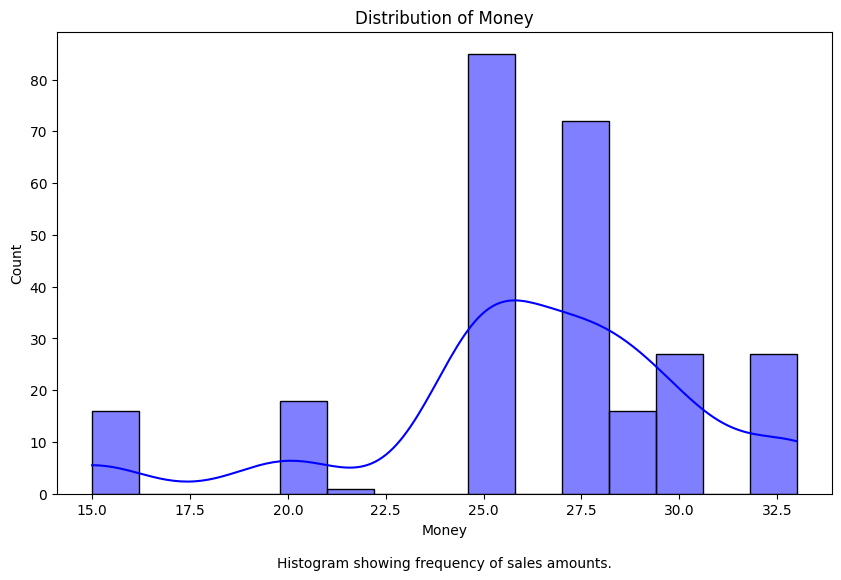

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['money'], kde=True, color='blue')
plt.title('Distribution of Money')
plt.xlabel('Money')
plt.text(0.5, -0.15, "Histogram showing frequency of sales amounts.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

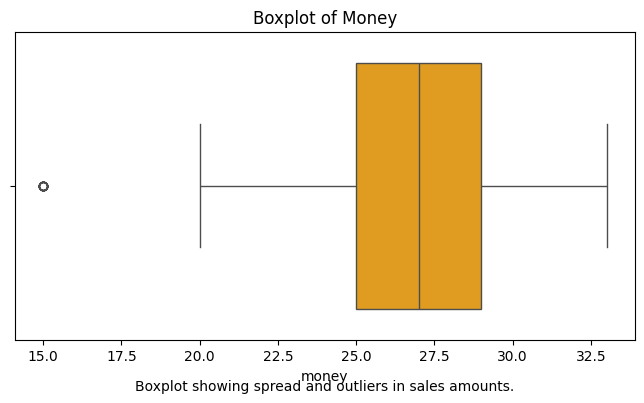

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['money'], color='orange')
plt.title('Boxplot of Money')
plt.text(0.5, -0.15, "Boxplot showing spread and outliers in sales amounts.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

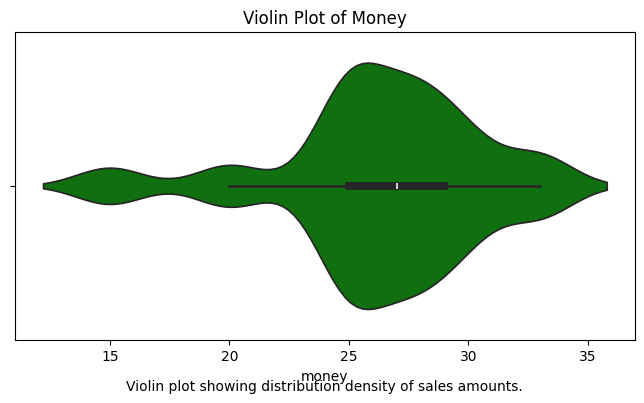

In [15]:
plt.figure(figsize=(8,4))
sns.violinplot(x=df['money'], color='green')
plt.title('Violin Plot of Money')
plt.text(0.5, -0.15, "Violin plot showing distribution density of sales amounts.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

#### b) Frequency of Coffee Types and Cash Types

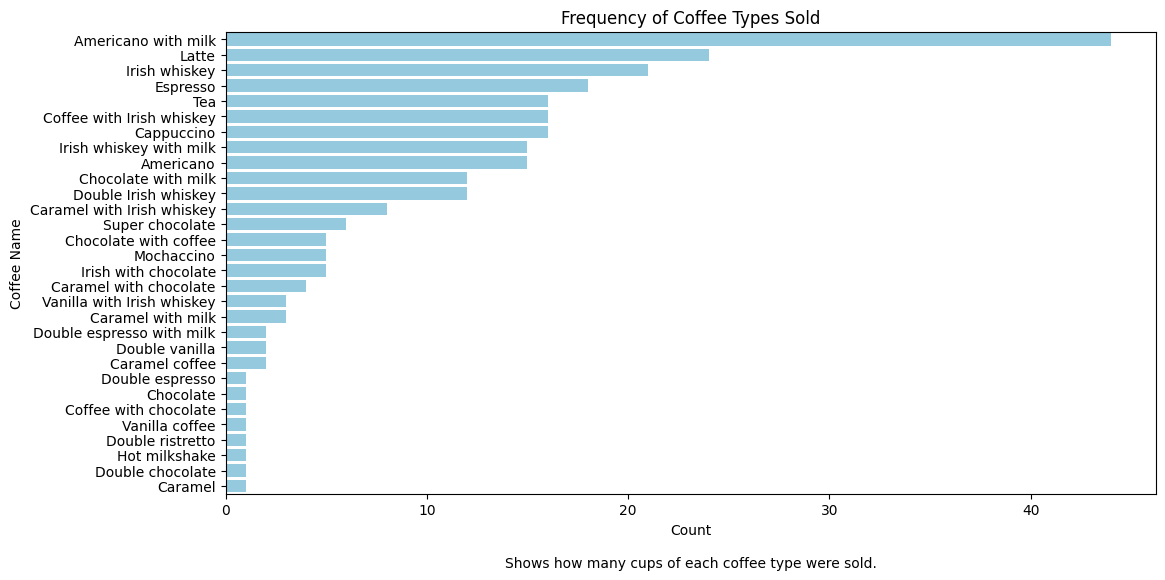

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(y='coffee_name', data=df, order=df['coffee_name'].value_counts().index, color='skyblue')
plt.title('Frequency of Coffee Types Sold')
plt.xlabel('Count')
plt.ylabel('Coffee Name')
plt.text(0.5, -0.15, "Shows how many cups of each coffee type were sold.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

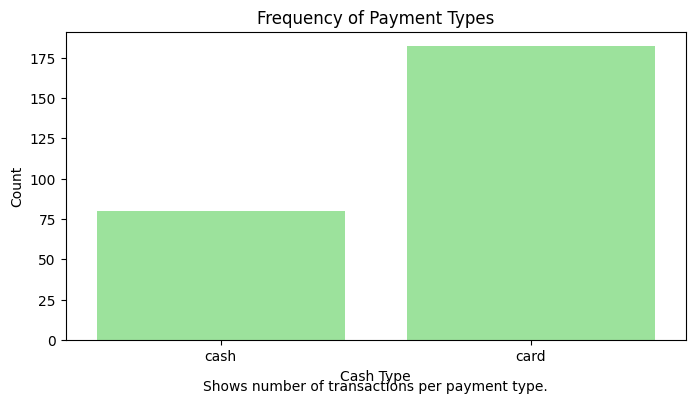

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(x='cash_type', data=df, color='lightgreen')
plt.title('Frequency of Payment Types')
plt.xlabel('Cash Type')
plt.ylabel('Count')
plt.text(0.5, -0.15, "Shows number of transactions per payment type.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

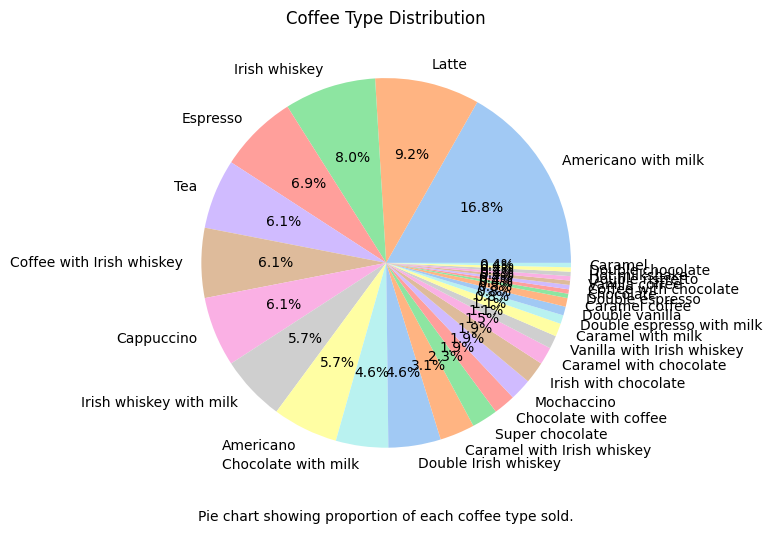

In [18]:
plt.figure(figsize=(6,6))
df['coffee_name'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Coffee Type Distribution')
plt.ylabel('')
plt.text(0.5, -0.05, "Pie chart showing proportion of each coffee type sold.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

### 6. Bivariate Analysis

#### a) Numerical vs Categorical

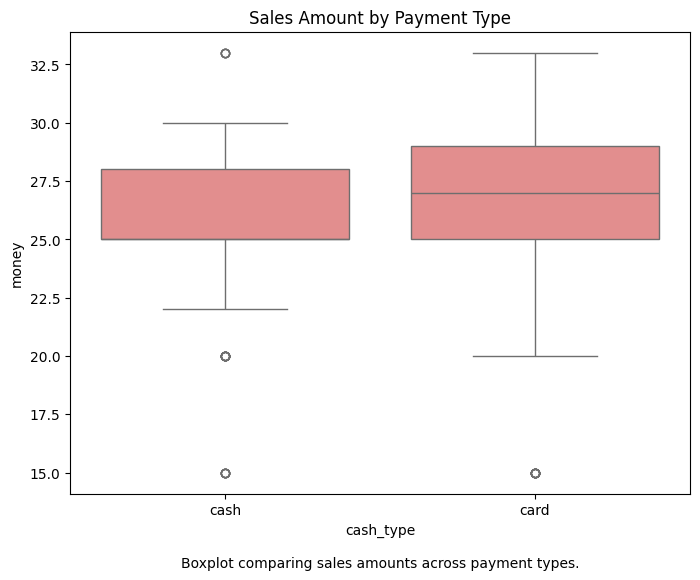

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cash_type', y='money', data=df, color='lightcoral')
plt.title('Sales Amount by Payment Type')
plt.text(0.5, -0.15, "Boxplot comparing sales amounts across payment types.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

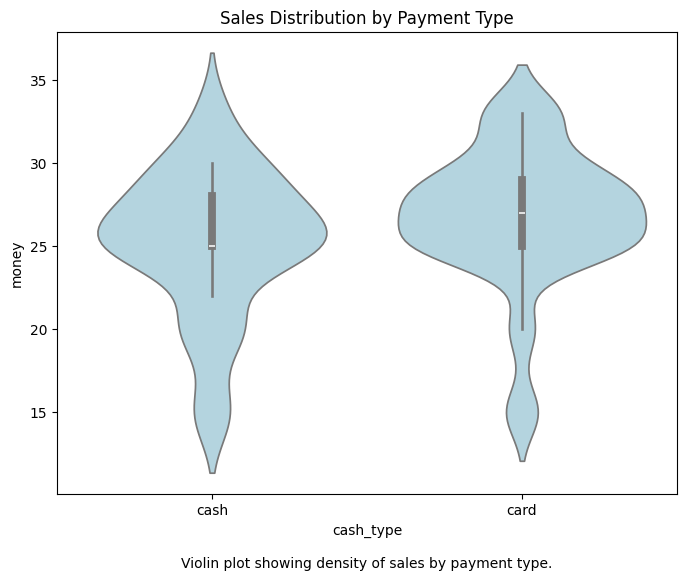

In [20]:
plt.figure(figsize=(8,6))
sns.violinplot(x='cash_type', y='money', data=df, color='lightblue')
plt.title('Sales Distribution by Payment Type')
plt.text(0.5, -0.15, "Violin plot showing density of sales by payment type.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

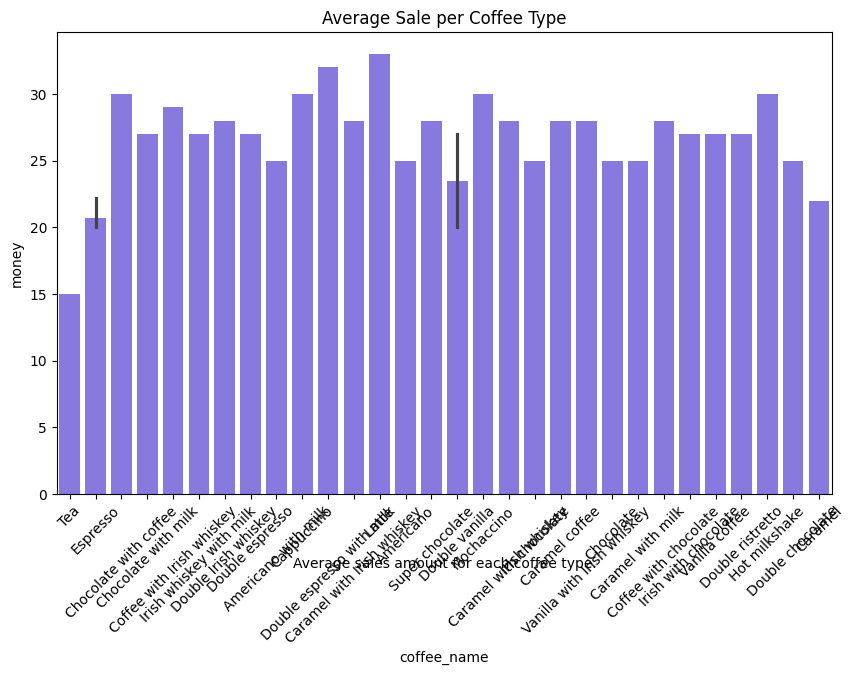

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='coffee_name', y='money', data=df, estimator=np.mean, color='mediumslateblue')
plt.title('Average Sale per Coffee Type')
plt.xticks(rotation=45)
plt.text(0.5, -0.15, "Average sales amount for each coffee type.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

#### b) Categorical vs Categorical

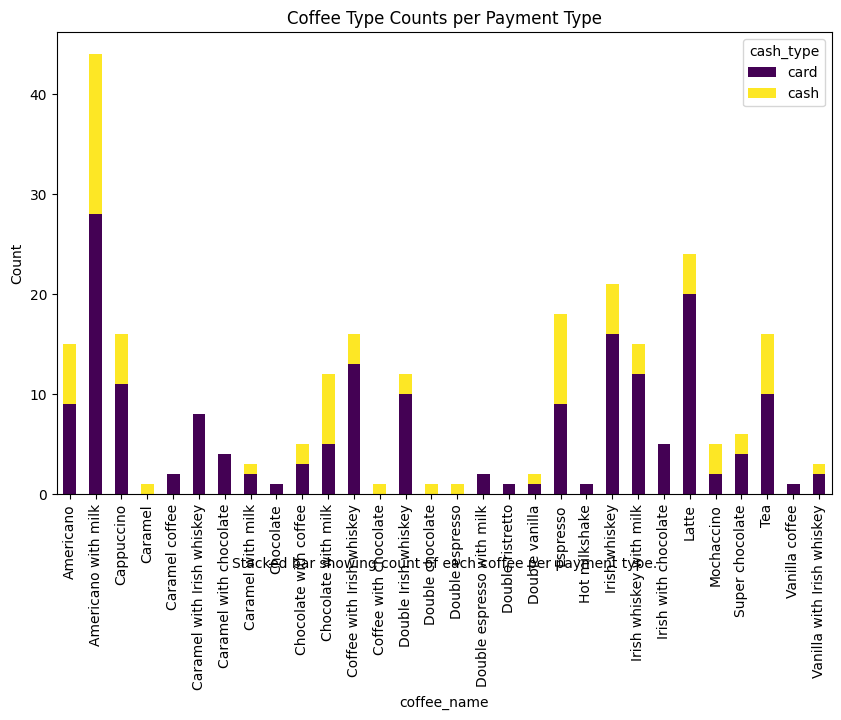

In [22]:
ct = pd.crosstab(df['coffee_name'], df['cash_type'])

ct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Coffee Type Counts per Payment Type')
plt.ylabel('Count')
plt.text(0.5, -0.15, "Stacked bar showing count of each coffee per payment type.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

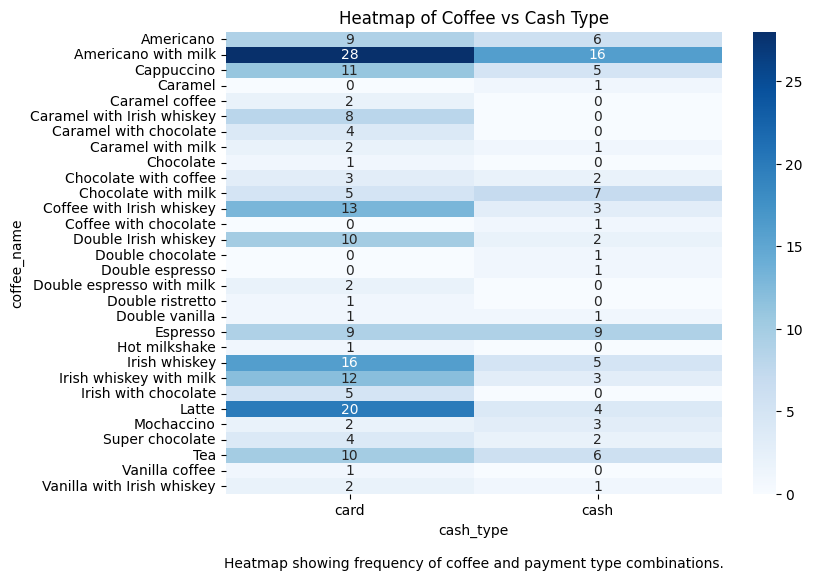

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Coffee vs Cash Type')
plt.text(0.5, -0.15, "Heatmap showing frequency of coffee and payment type combinations.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

#### c) Numerical vs Numerical

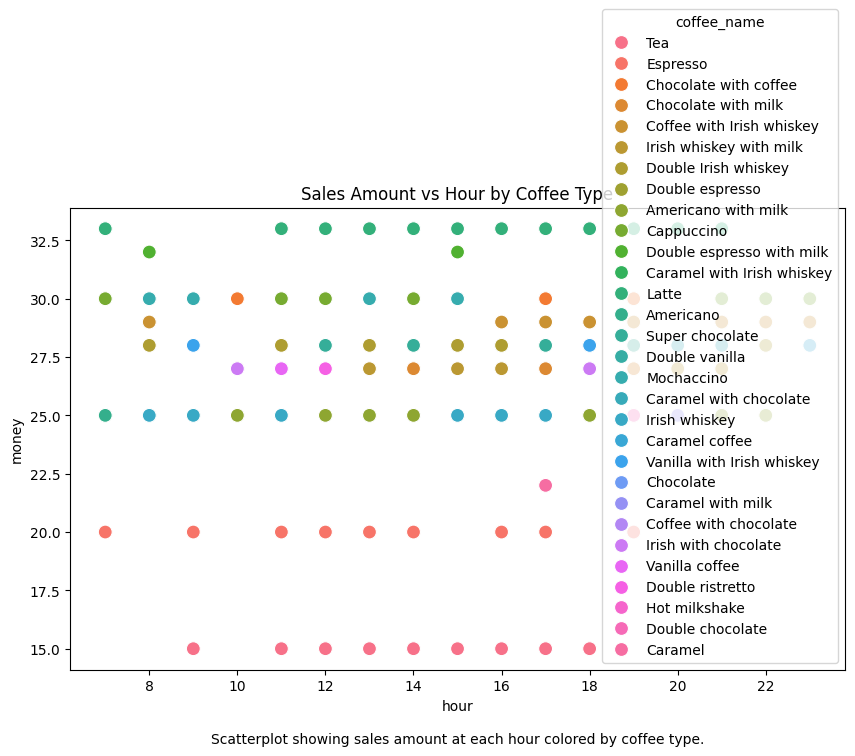

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='hour', y='money', data=df, hue='coffee_name', s=100)
plt.title('Sales Amount vs Hour by Coffee Type')
plt.text(0.5, -0.15, "Scatterplot showing sales amount at each hour colored by coffee type.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

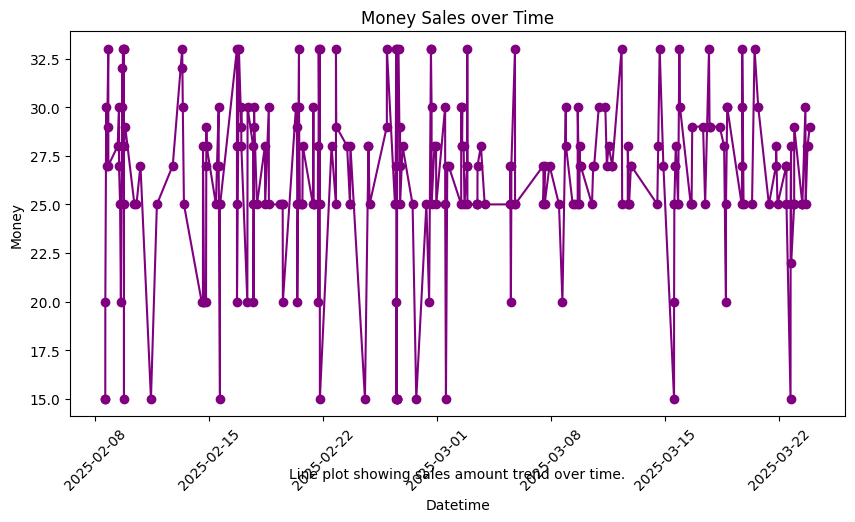

In [25]:
df_sorted = df.sort_values('datetime')
plt.figure(figsize=(10,5))
plt.plot(df_sorted['datetime'], df_sorted['money'], marker='o', color='purple')
plt.title('Money Sales over Time')
plt.xlabel('Datetime')
plt.ylabel('Money')
plt.xticks(rotation=45)
plt.text(0.5, -0.15, "Line plot showing sales amount trend over time.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

### 7. Time-Based Analysis

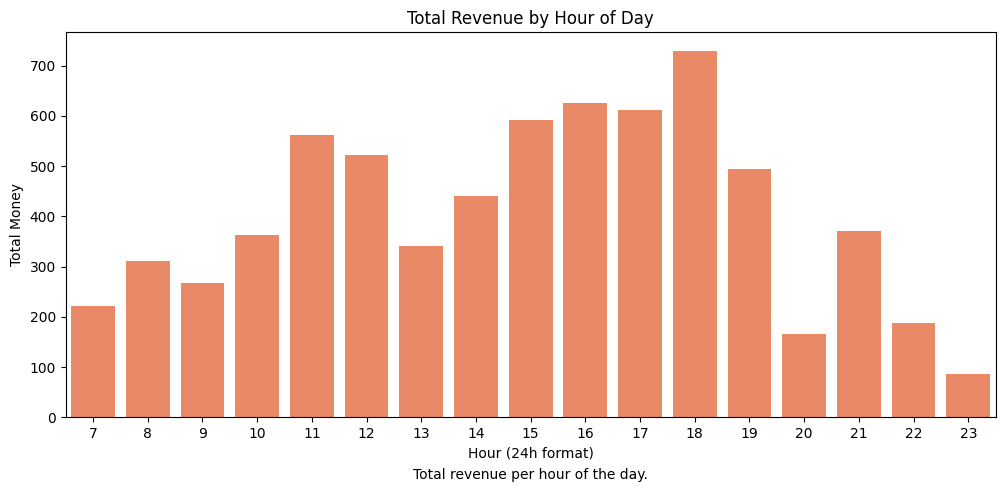

In [26]:
plt.figure(figsize=(12,5))
sns.barplot(x='hour', y='money', data=df, estimator=sum, errorbar=None, color='coral')
plt.title("Total Revenue by Hour of Day")
plt.xlabel("Hour (24h format)")
plt.ylabel("Total Money")
plt.text(0.5, -0.15, "Total revenue per hour of the day.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

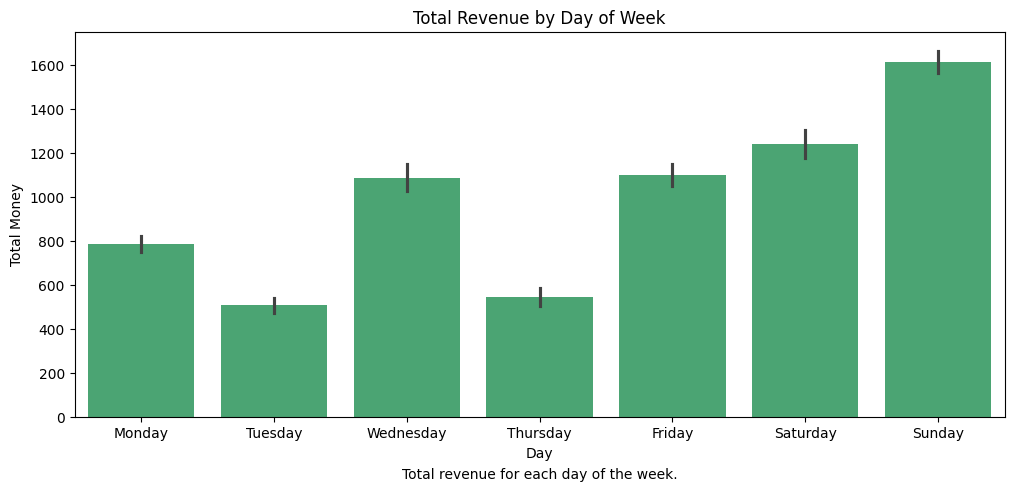

In [27]:
plt.figure(figsize=(12,5))
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(x='day_of_week', y='money', data=df, estimator=sum, order=order_days, color='mediumseagreen')
plt.title("Total Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Money")
plt.text(0.5, -0.15, "Total revenue for each day of the week.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()

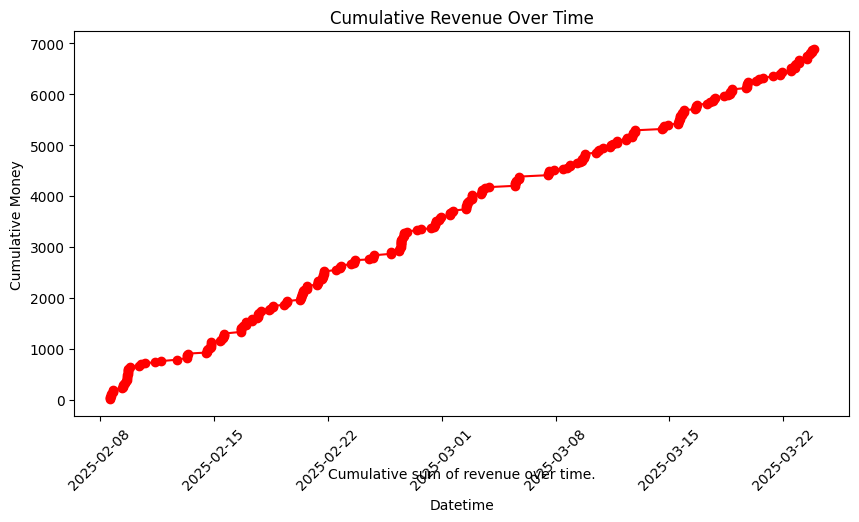

In [28]:
df['cumulative_money'] = df['money'].cumsum()
plt.figure(figsize=(10,5))
plt.plot(df['datetime'], df['cumulative_money'], marker='o', color='red')
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Datetime')
plt.ylabel('Cumulative Money')
plt.xticks(rotation=45)
plt.text(0.5, -0.15, "Cumulative sum of revenue over time.", ha='center', va='center', transform=plt.gca().transAxes)
plt.show()